# Conda Environment: diversity

---

# Library Imports

In [1]:
# For suppressing warnings
import warnings
warnings.filterwarnings(action='ignore', category= UserWarning)

# import OS for shell functionality
import os

# for python data manipulation and plotting
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# for running R through Python
import rpy2.robjects as ro
from rpy2.robjects.packages import importr

# Load the rpy2 extension
%load_ext rpy2.ipython

# R libraries needed
vegan = importr('vegan')
dplyr = importr('dplyr')
tidyr = importr('tidyr')
purrr = importr('purrr')

---

## Creating Output Directories

In [2]:
# Create output directory for 
!mkdir -p ../Datasets/SequenceTables        # Sequence tables
!mkdir -p ../Datasets/Diversity/Alpha       # Diversity tables
!mkdir -p ../Figures/Diversity/Alpha       # Diversity tables

---

# Import Sample Metadata

In [3]:
sample_data = pd.read_csv("../Datasets/sample-data.csv")
sample_data['Temperature'] = sample_data['Temperature'].astype('Int64')

---

# Calculating Diversity

## Importing and Subsetting Data

In [4]:
# Import data
asv = pd.read_csv("../Datasets/Input/cleaned_ASV_table.tsv", sep="\t", index_col=0)    # Sequence table from Ampliseq

# Subset to stage 1 and stage 2 datasets
s1 = asv[sample_data[sample_data['Stage'] == 1]['Sample']]
s2 = asv[sample_data[sample_data['Stage'] == 2]['Sample']]

# Subset each to active and resident
s1_active = asv[sample_data[(sample_data['Stage'] == 1) & (sample_data['Active'] == 1)]['Sample']]
s2_active = asv[sample_data[(sample_data['Stage'] == 2) & (sample_data['Active'] == 1)]['Sample']]
s1_resident = asv[sample_data[(sample_data['Stage'] == 1) & (sample_data['Active'] == 0)]['Sample']]
s2_resident = asv[sample_data[(sample_data['Stage'] == 2) & (sample_data['Active'] == 0)]['Sample']]

# Get resident data for

## Stages 1 & 2 Week 8
s1_resident_w8 = asv[sample_data[(sample_data['Stage'] == 1) & (sample_data['Active'] == 0) &
                     (sample_data['Time point (week)'] == 8)]['Sample']]
s2_resident_w8 = asv[sample_data[(sample_data['Stage'] == 2) & (sample_data['Active'] == 0) &
                     (sample_data['Time point (week)'] == 8)]['Sample']]
## Stage 2 Week 6
s2_resident_w6 = asv[sample_data[(sample_data['Stage'] == 2) & (sample_data['Active'] == 0) &
                     (sample_data['Time point (week)'] == 6)]['Sample']]

## Stage 2 Week 4
s2_resident_w4 = asv[sample_data[(sample_data['Stage'] == 2) & (sample_data['Active'] == 0) &
                     (sample_data['Time point (week)'] == 4)]['Sample']]

## Stage 2 Week 2
s2_resident_w2 = asv[sample_data[(sample_data['Stage'] == 2) & (sample_data['Active'] == 0) &
                     (sample_data['Time point (week)'] == 2)]['Sample']]

# Export to files
s1.to_csv("../Datasets/SequenceTables/StageOne.csv")
s2.to_csv("../Datasets/SequenceTables/StageTwo.csv")
s1_active.to_csv("../Datasets/SequenceTables/StageOneActive.csv")
s2_active.to_csv("../Datasets/SequenceTables/StageTwoActive.csv")
s1_resident.to_csv("../Datasets/SequenceTables/StageOneResident.csv")
s2_resident.to_csv("../Datasets/SequenceTables/StageTwoResident.csv")
s1_resident_w8.to_csv("../Datasets/SequenceTables/StageOneResidentWeekEight.csv")
s2_resident_w8.to_csv("../Datasets/SequenceTables/StageTwoResidentWeekEight.csv")
s2_resident_w6.to_csv("../Datasets/SequenceTables/StageTwoResidentWeekSix.csv")
s2_resident_w4.to_csv("../Datasets/SequenceTables/StageTwoResidentWeekFour.csv")
s2_resident_w2.to_csv("../Datasets/SequenceTables/StageTwoResidentWeekTwo.csv")

## Diversity Calculations by Rarefaction

In [5]:
subsets = ['StageOneActive', 'StageTwoActive', 'StageOneResidentWeekEight', 'StageTwoResidentWeekEight']

# Loop to rarefy community to the smallest number of reads in each subset,
# calculate diversity, and append values to a file
for subset in subsets:
    n = 1
    input_path = "../Datasets/SequenceTables"
    output_path = "../Datasets/Diversity/Alpha"
    
    # Get sample numbers to use as column names
    df = pd.read_csv(f"{input_path}/{subset}.csv")
    columns = df.columns[1:]
    
    # Create empty csv file to append data to
    output = pd.DataFrame(columns= columns)
    output.to_csv(f"{output_path}/{subset}_diversity.csv", index= False)
    
    # Loop to calculate rarefied diversity 100 times
    while n <= 100:
        ro.r(f'''
        # Import data
        data = read.csv('{input_path}/{subset}.csv', row.names=1)
        data = t(data)
        
        # Calculate size to subset to
        size = min(rowSums(data))
        
        # Subsample community without replacement to that size
        data = rrarefy(data, size)
        
        # Calculate Shannon diversity on rarefied community
        shannon = diversity(data, index= 'shannon')
        names(shannon) = rownames(data)
        shannon = t(data.frame(shannon))
        
        # Append as new row to output
        write.table(shannon, "{output_path}/{subset}_diversity.csv", sep = ",", col.names = FALSE, row.names = FALSE, append = TRUE)
        ''')
        n += 1
        

## Plotting of Rarefied Diversity

### Import and format data

In [5]:
# Import diversity data
input_path = "../Datasets/Diversity/Alpha"
output_path = input_path

s1_active_diversity = pd.read_csv(f"{input_path}/StageOneActive_diversity.csv")
s2_active_diversity = pd.read_csv(f"{input_path}/StageTwoActive_diversity.csv")
s1_resident_w8_diversity = pd.read_csv(f"{input_path}/StageOneResidentWeekEight_diversity.csv")
s2_resident_w8_diversity = pd.read_csv(f"{input_path}/StageTwoResidentWeekEight_diversity.csv")

# Convert to long format
s1_active_diversity = pd.melt(s1_active_diversity, var_name= "Sample", value_name= "Diversity")
s2_active_diversity = pd.melt(s2_active_diversity, var_name= "Sample", value_name= "Diversity")
s1_resident_w8_diversity = pd.melt(s1_resident_w8_diversity, var_name= "Sample", value_name= "Diversity")
s2_resident_w8_diversity = pd.melt(s2_resident_w8_diversity, var_name= "Sample", value_name= "Diversity")

# Take the mean estimated diversity per sample
s1_active_diversity = s1_active_diversity.groupby('Sample').mean()
s2_active_diversity = s2_active_diversity.groupby('Sample').mean(numeric_only= True)
s1_resident_w8_diversity = s1_resident_w8_diversity.groupby('Sample').mean()
s2_resident_w8_diversity = s2_resident_w8_diversity.groupby('Sample').mean(numeric_only= True)

# Merge with sample metadata
s1_active_diversity = pd.merge(left= s1_active_diversity, right= sample_data[['Sample','Temperature']],
                               how= 'left', on= 'Sample')
s2_active_diversity = pd.merge(left= s2_active_diversity, right= sample_data[['Sample','Scale of fluctuation']],
                               how= 'left', on= 'Sample')
s1_resident_w8_diversity = pd.merge(left= s1_resident_w8_diversity, right= sample_data[['Sample','Temperature']],
                               how= 'left', on= 'Sample')
s2_resident_w8_diversity = pd.merge(left= s2_resident_w8_diversity, right= sample_data[['Sample','Scale of fluctuation']],
                               how= 'left', on= 'Sample')

# Export to files
s1_active_diversity.to_csv(f"{output_path}/StageOneActive_diversity_averaged.csv")
s2_active_diversity.to_csv(f"{output_path}/StageTwoActive_diversity_averaged.csv")
s1_resident_w8_diversity.to_csv(f"{output_path}/StageOneResidentWeekEight_diversity_averaged.csv")
s2_resident_w8_diversity.to_csv(f"{output_path}/StageTwoResidentWeekEight_diversity_averaged.csv")

### Plot diversity by temperature

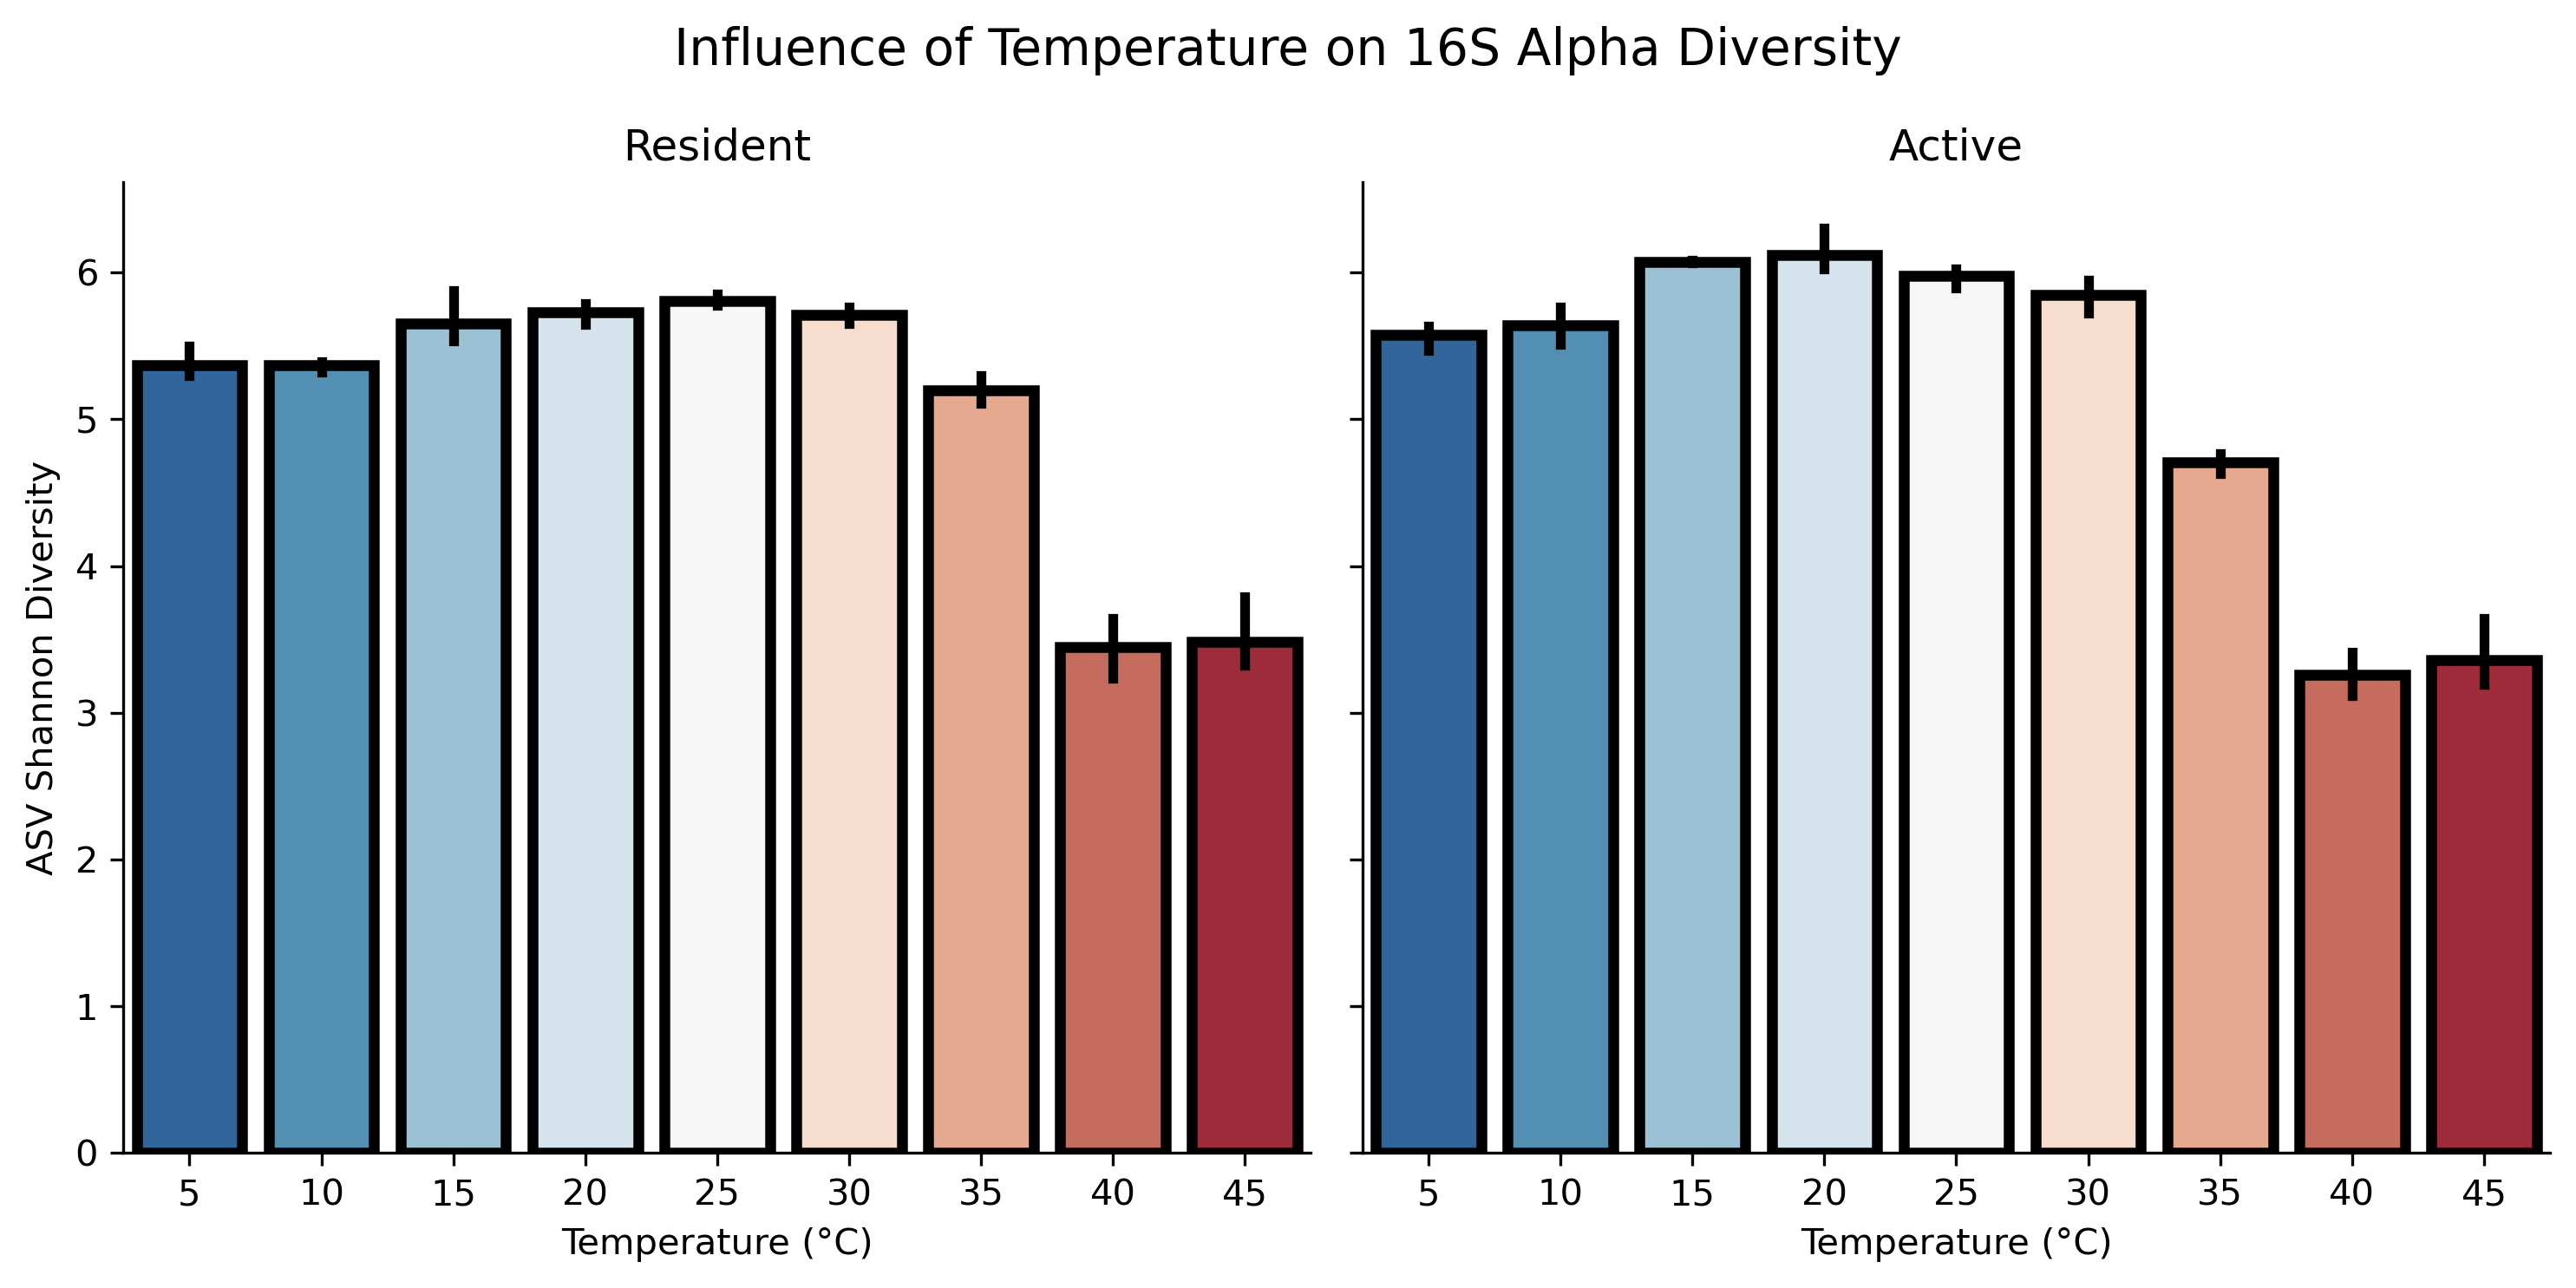

In [6]:
# Plot
fig, axes = plt.subplots(nrows= 1, ncols= 2, figsize= (10,5), dpi= 300, sharey= True)
fig.suptitle('Influence of Temperature on 16S Alpha Diversity', fontsize= 14)

## Set up colour palette
colours= sns.color_palette("RdBu_r",9)
colours = dict(zip(sample_data['Temperature'].dropna().unique(),colours))

## X labels
xlabels = sample_data['Temperature'].dropna().unique()

# Stage 1 resident data
sns.barplot(data= s1_resident_w8_diversity, x= "Temperature", y= "Diversity", palette= colours, estimator='mean',
            errorbar=('ci', 95), errcolor= 'black', linewidth= 3, edgecolor= 'black', ax= axes[0])
axes[0].set(ylabel= "ASV Shannon Diversity",xlabel= 'Temperature (°C)', title= 'Resident', xticklabels= xlabels)

# Stage 1 active data
sns.barplot(data= s1_active_diversity, x= "Temperature", y= "Diversity", palette= colours, estimator='mean',
            errorbar=('ci', 95), errcolor= 'black', linewidth= 3, edgecolor= 'black', ax= axes[1])
axes[1].set(ylabel= None, xlabel= 'Temperature (°C)', title= 'Active', xticklabels= xlabels)

# Tidy up
sns.despine()
plt.tight_layout()

# Save figure
plt.savefig("../Figures/Diversity/Alpha/Shannon_diversity_temperature.svg")

### Graph of Diversity by Temperature

#### Test model fits

In [7]:
# Define function for AICc calculation

def calculate_AICc(residuals, degree):
    residuals = np.array(residuals)
    k = degree + 1  # Number of parameters (degree + 1 for polynomial coefficients)
    n = len(residuals)
    SSR = np.sum(residuals ** 2)  # Sum of squared residuals
    sigma2 = SSR / (n-k)  # Residual variance
    
    AIC = n * np.log(sigma2) + 2 * k
    AICc = AIC + (2 * k * (k + 1)) / (n - k - 1) 

    return sigma2,AICc

In [8]:
fits = []

fit_data = s1_active_diversity.copy()

for degree in range(10):
    # Fit polynomial model with specified order
    polyfit = np.polynomial.Polynomial.fit(x= fit_data['Temperature'].astype(float),
                                           y= fit_data['Diversity'], deg= degree)

    # Calculate y values using model
    y_fitted = [polyfit(value) for value in fit_data['Temperature']]
    y_fitted = np.array(y_fitted)

    # Get true y values
    y_true = list(fit_data['Diversity'])
    y_true = np.array(y_true)

    # Calculate residuals
    residuals = y_true - y_fitted

    # AIC calculation
    residual_variance, AICc_value = calculate_AICc(residuals, degree)
    
    # Append to list
    fits.append([degree, residual_variance, AICc_value])

# Convert to dataframe    
fits = pd.DataFrame(fits, columns= ['Polynomial Order','Residual Variance' ,'AICc'])

# Find polynomial model with best fit
best_fit= fits[fits['AICc'] == fits['AICc'].min()]['Polynomial Order'].iloc[0]

fits.to_csv("../Datasets/Diversity/Alpha/Polynomial_fits.csv", index= False)

fits


,Polynomial Order,Residual Variance,AICc
0,0,1.209808,7.302459
1,1,0.533645,-12.456635
2,2,0.132282,-47.572634
3,3,0.133485,-44.553413
4,4,0.056760,-64.603984
5,5,0.032334,-76.454176
6,6,0.019150,-86.902429
7,7,0.018279,-84.054615
8,8,0.017431,-80.748638
9,9,0.018456,-74.043596


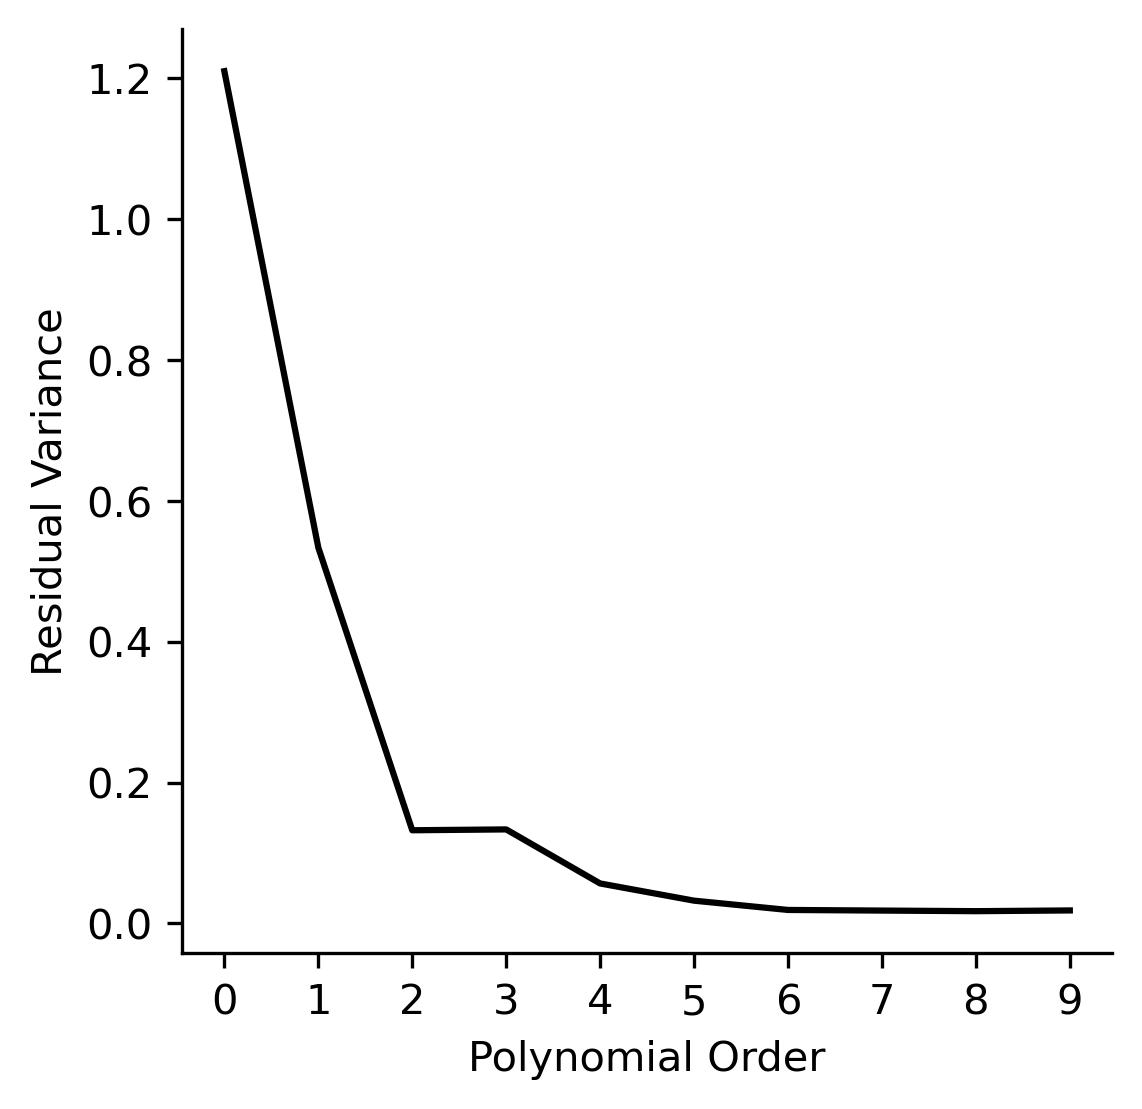

In [9]:
plt.figure(figsize= (4,4), dpi= 300)
sns.lineplot(data= fits, x= 'Polynomial Order', y= 'Residual Variance', color= 'black')
plt.xticks(range(10))
sns.despine()
plt.savefig("../Figures/Diversity/Alpha/Residual_variance_by_polynomial_order.svg")

Despite lower AICc values for higher polynomial orders, it appears to be due to overfitting to noise in the data. The largest drop in unexplained variance is associated with using a polynomial order of 2 (quadratic), after which decreases are modest. Accordingly, a quadratic relationship best accounts for the trend in diversity with temperature while remaining biologically meaningful.

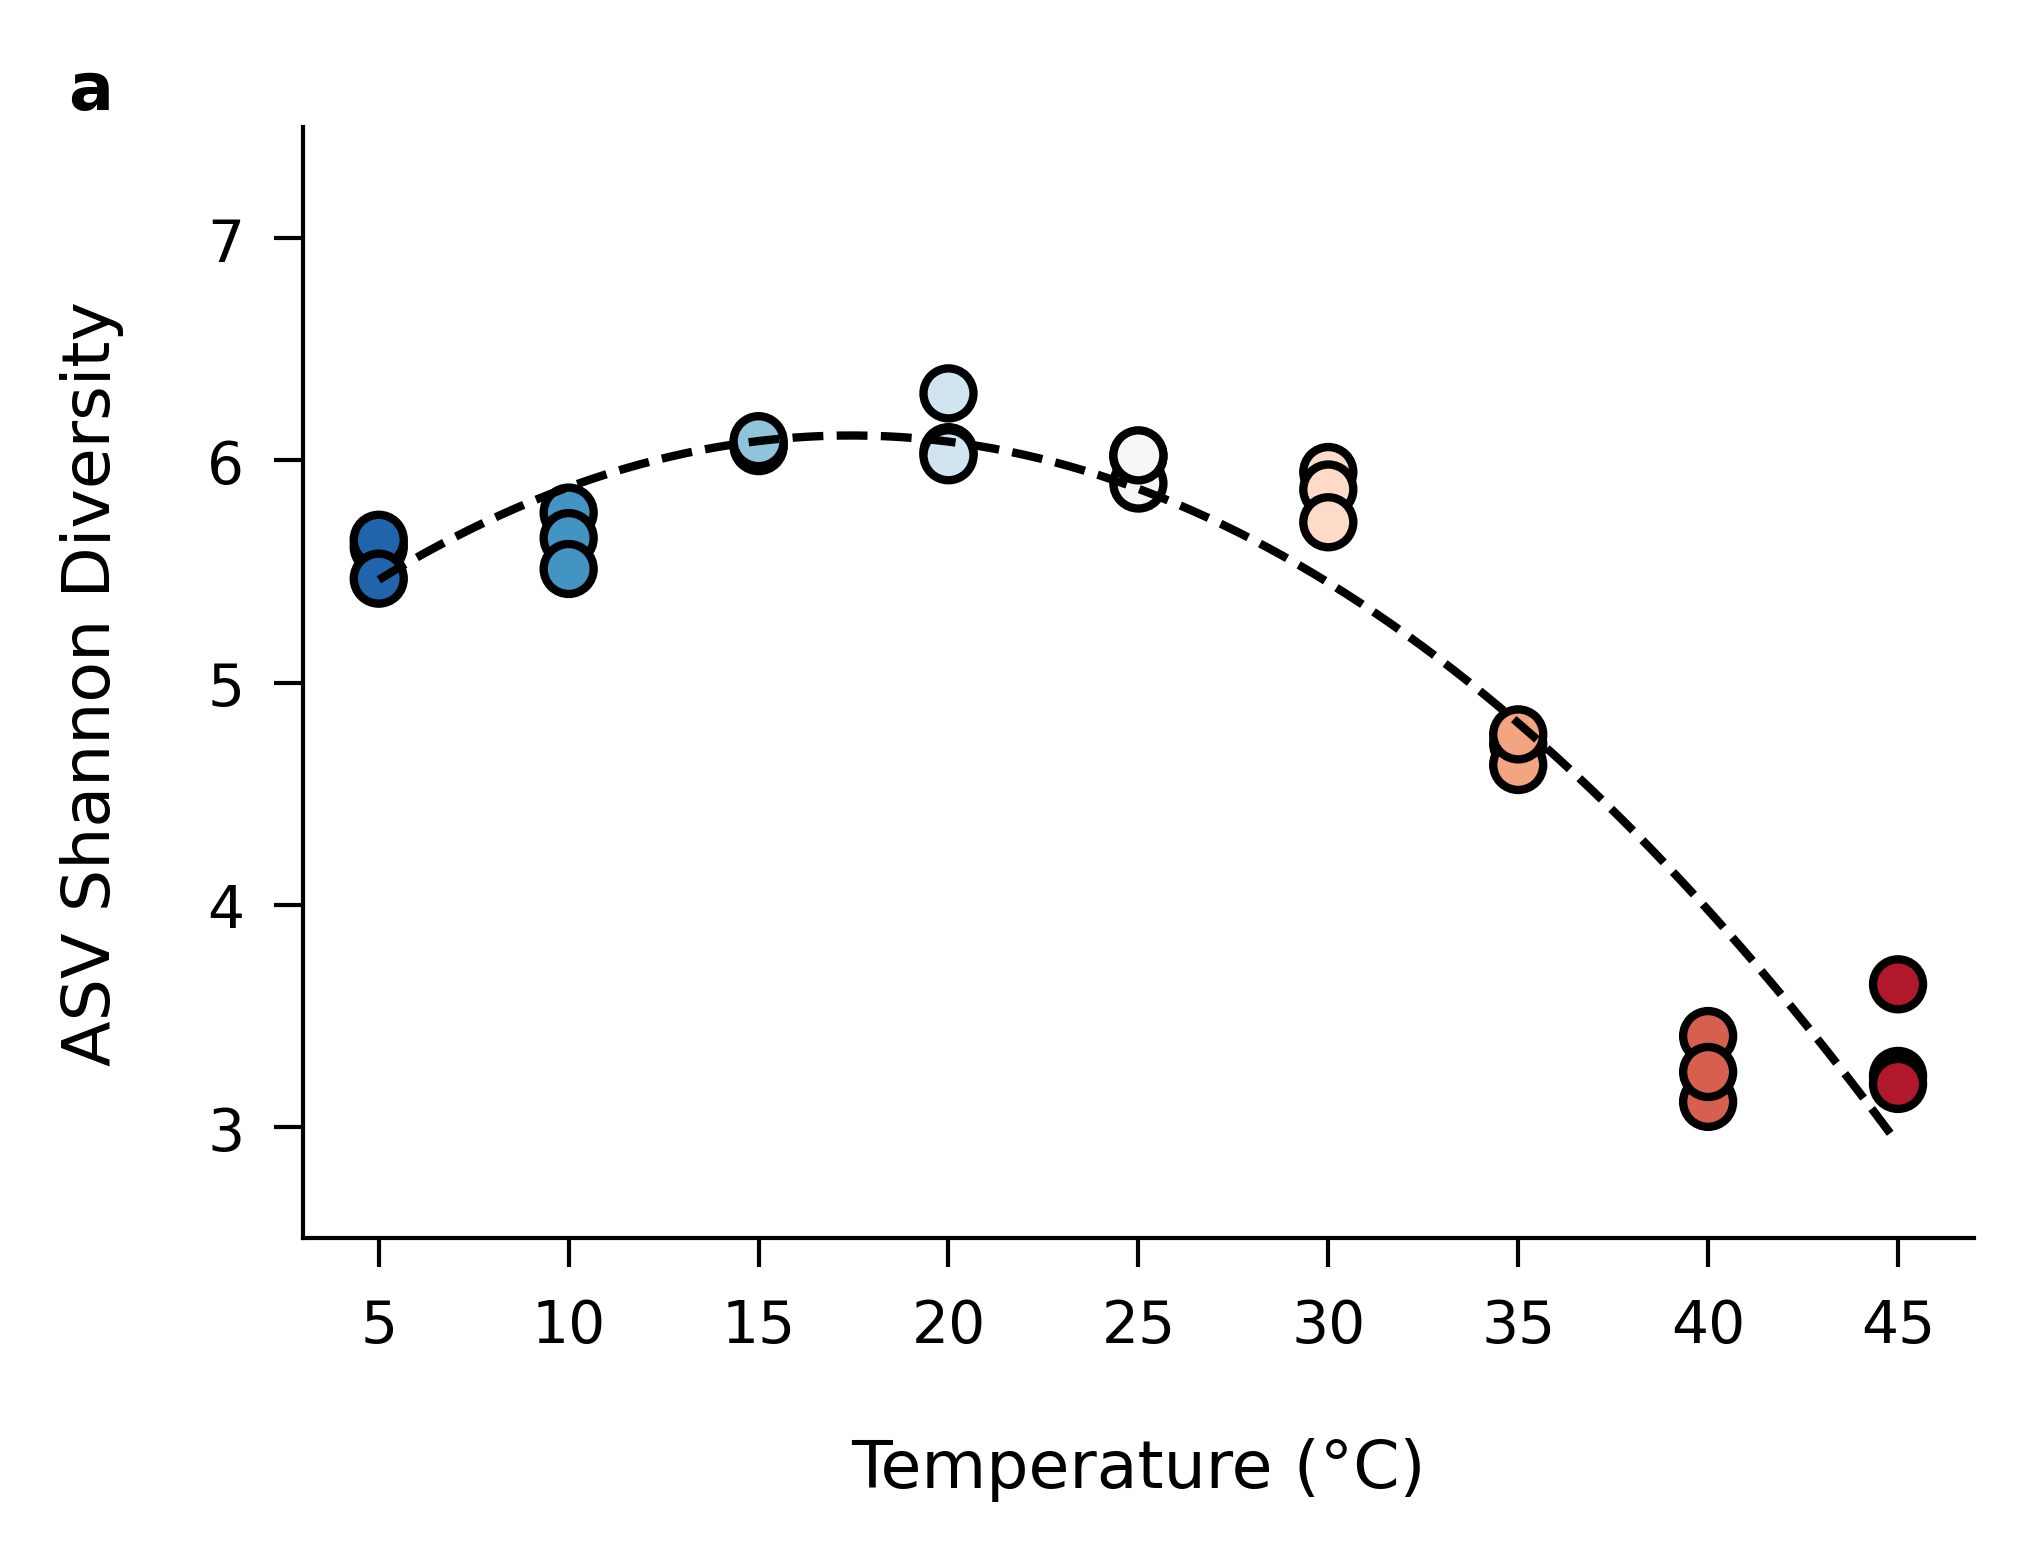

In [10]:
plt.style.use("../nature.mplstyle")

# Create plot data variable
plot_data = s1_active_diversity.copy()

# X labels
xlabels = sample_data['Temperature'].dropna().unique()

# Choose polynomial order
poly_order = 2

# Colour Palette
## Create groups for colouring
plot_data['Group'] = plot_data['Temperature'].astype(int)
## Set up colour palette
colours= sns.color_palette("RdBu_r",9)
colours = dict(zip(sample_data['Temperature'].dropna().unique(),colours))

# Plot
## Make empty figure
fig = plt.figure(figsize= (3.4,2.5), dpi= 600)
## Plot real diversity data
p = sns.scatterplot(data= plot_data, x= "Temperature", y= "Diversity",hue= 'Group', palette= colours,
                    linewidth= 1, edgecolor= 'black', legend= False)


## Add polynomial fit
polyfit = np.polynomial.Polynomial.fit(x= plot_data['Temperature'].astype(float),
                                       y= plot_data['Diversity'], deg= poly_order)
predicted_diversity = polyfit.linspace()
sns.lineplot(x= predicted_diversity[0], y= predicted_diversity[1], color= 'black', linestyle= '--', alpha= 1, ax= p)


# Tidy up
plt.ylim((2.5,7.5))
plt.ylabel("ASV Shannon Diversity", labelpad= 10)
plt.xlabel("Temperature (°C)", labelpad= 10)
sns.despine()
#plt.text(x= -3.2, y=7.3 , s= 'a', weight= 'bold', fontsize= 8)
fig.text(x= 0.035, y=0.97 , s= 'a', weight= 'bold', fontsize= 8)
plt.tight_layout()

# Save to file
plt.savefig("../Figures/Diversity/Alpha/Diversity_by_Temperature_Model.svg");

### Extract peak of diversity

In [11]:
np.round(predicted_diversity[0][np.argmax(predicted_diversity[1])],1)

17.5

---

### Plot diversity by scale of temperature fluctuation

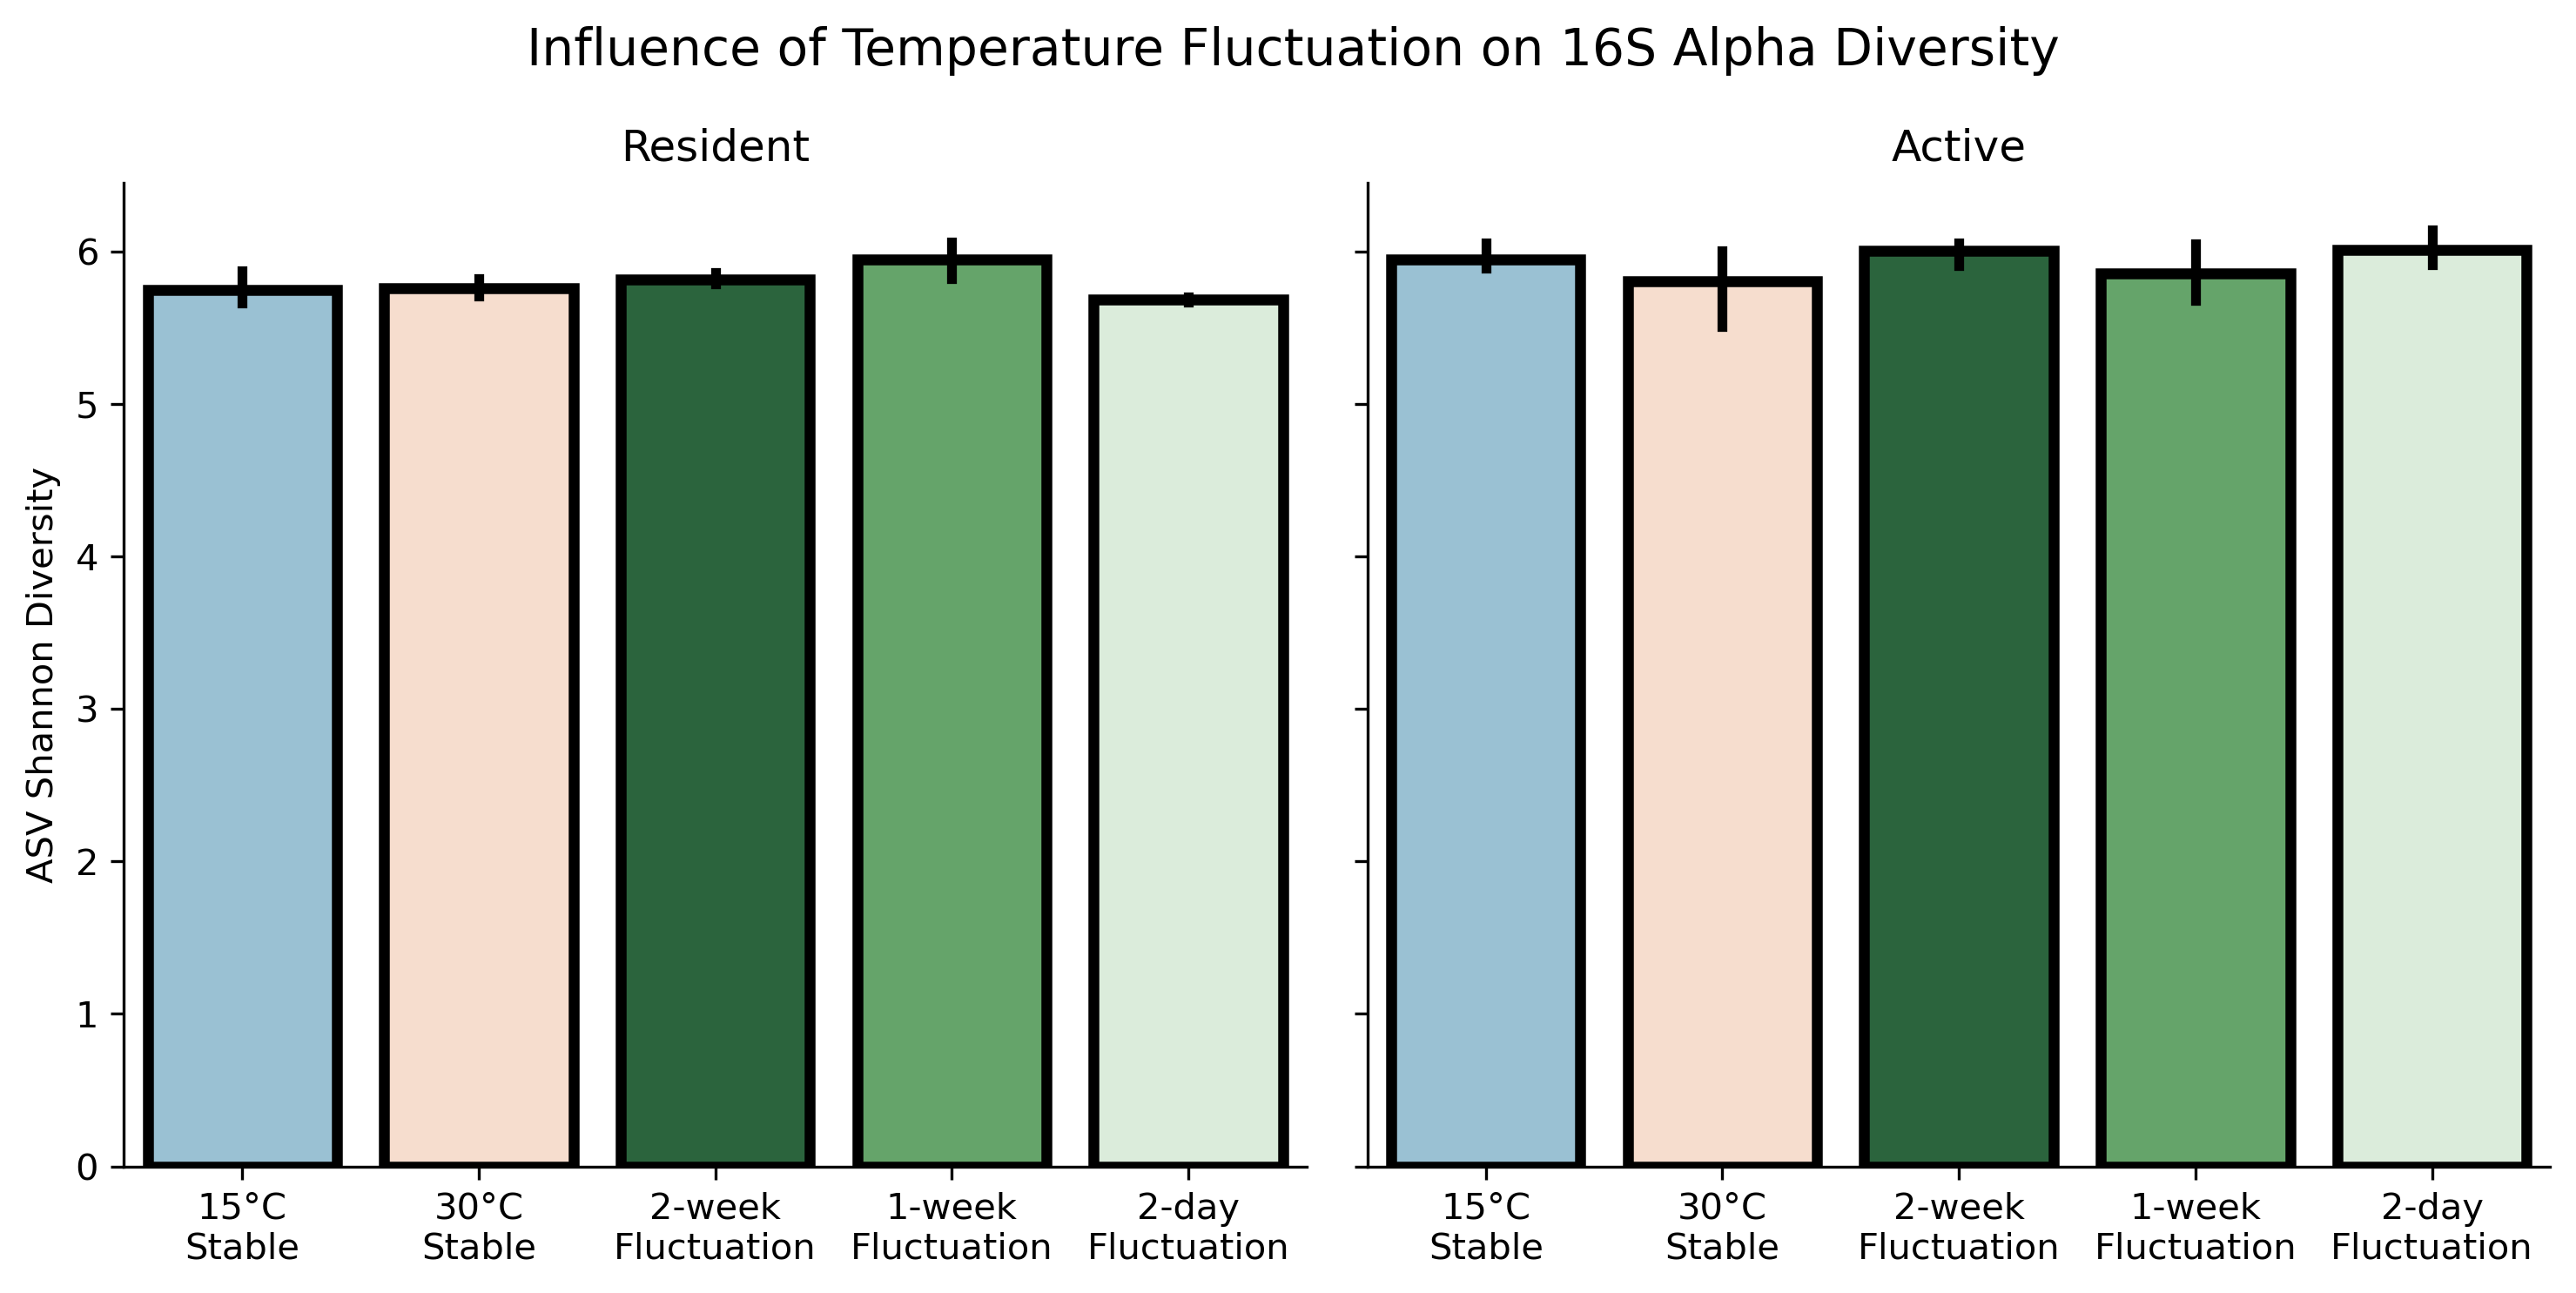

In [6]:
# Plot
fig, axes = plt.subplots(nrows= 1, ncols= 2, figsize= (10,5), dpi= 300, sharey= True)
fig.suptitle('Influence of Temperature Fluctuation on 16S Alpha Diversity', fontsize= 14)

# create order for scales of fluctuation
order = ['lowT','highT','2Weeks','1Week','2Days']
# create colour palette
colours = ['#90c4dd','#fddbc7','#216E39','#5AAE61','#D8EFD8']
# create x tick labels
xlabels = ['15°C\nStable','30°C\nStable', '2-week\nFluctuation','1-week\nFluctuation', '2-day\nFluctuation']

# Stage 2 resident data
sns.barplot(data= s2_resident_w8_diversity, x= "Scale of fluctuation", y= "Diversity", order= order, palette= colours,
            estimator='mean', errorbar=('ci', 95), errcolor= 'black', linewidth= 3, edgecolor= 'black', ax= axes[0])
axes[0].set(ylabel= "ASV Shannon Diversity",xlabel= None, title= 'Resident', xticklabels= xlabels)

# Stage 2 active data
sns.barplot(data= s2_active_diversity, x= "Scale of fluctuation", y= "Diversity", palette= colours, order= order,
            estimator='mean', errorbar=('ci', 95), errcolor= 'black', linewidth= 3, edgecolor= 'black', ax= axes[1])
axes[1].set(ylabel= None, xlabel= None, title= 'Active', xticklabels= xlabels)

# Tidy up
sns.despine()
plt.tight_layout()

# Save figure
plt.savefig("../Figures/Diversity/Alpha/Shannon_diversity_fluctuation.svg")

#### Test for normality of data within groups

In [7]:
%%R

# Import data
df = read.csv("../Datasets/Diversity/Alpha/StageTwoActive_diversity_averaged.csv")

# Loop through each group and apply the Shapiro-Wilk test
shapiro_results <- by(df$Diversity, df$Scale.of.fluctuation, shapiro.test)

# Print results
print(shapiro_results[[1]]$p)
print(shapiro_results[[2]]$p)
print(shapiro_results[[3]]$p)
print(shapiro_results[[4]]$p)
print(shapiro_results[[5]]$p)

[1] 0.8614483
[1] 0.5039256
[1] 0.2088316
[1] 0.3652709
[1] 0.1605706


All groups satisfy assumption of normal distribution.

#### Test for equality of variances

In [8]:
%%R
# Import data
df = read.csv("../Datasets/Diversity/Alpha/StageTwoActive_diversity_averaged.csv")

# Run Bartlett test for equality of variances and print p value
bartlett.test(x= df$Diversity,g= df$Scale.of.fluctuation, data= df)$p.value

[1] 0.5112749


Variances between groups are equal, appropriate to use ANOVA

#### One way ANOVA

In [9]:
%%R

# Import data
df = read.csv("../Datasets/Diversity/Alpha/StageTwoActive_diversity_averaged.csv")

# Run ANOVA
anova= aov(Diversity ~ Scale.of.fluctuation, data= df)

# Print results
print(summary(anova))

                     Df  Sum Sq Mean Sq F value Pr(>F)
Scale.of.fluctuation  4 0.09817 0.02454   0.926  0.487
Residuals            10 0.26519 0.02652               


Support for differences between the diversity for different scale of fluctuation treatment groups is weak (*p* = 0.49)

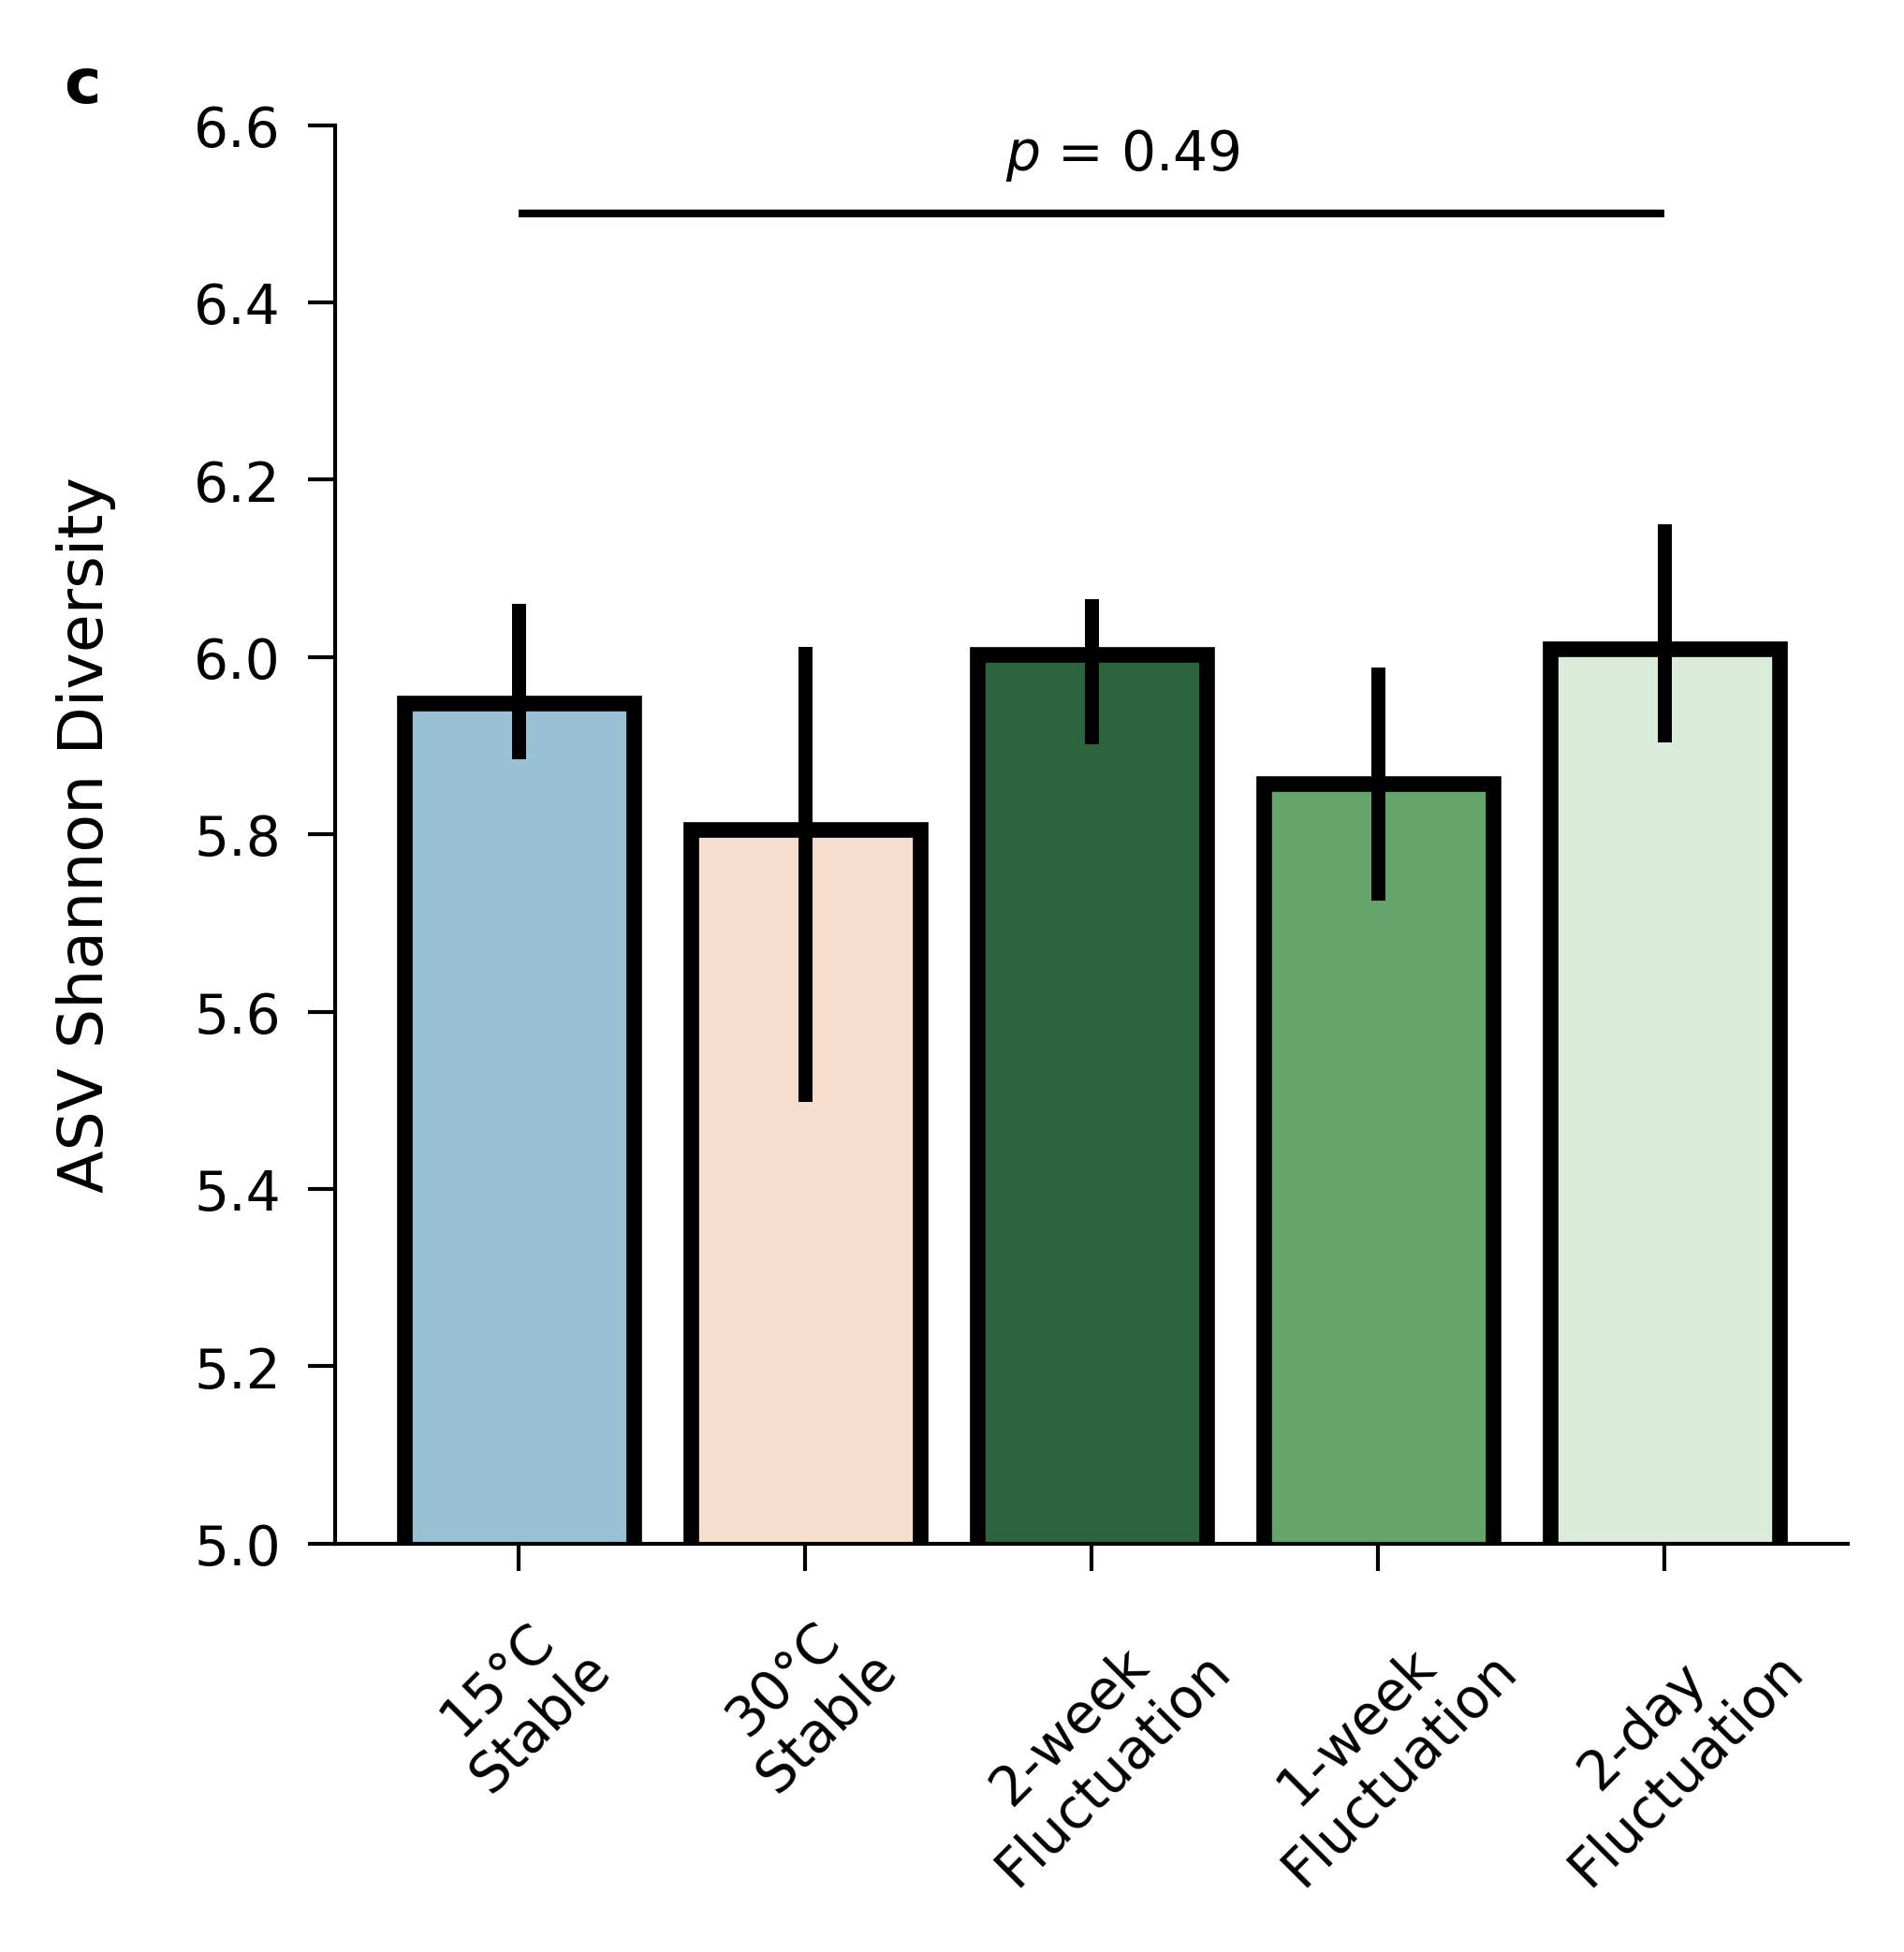

In [10]:
plt.style.use("../nature.mplstyle")

# Load data
s2_active_diversity = pd.read_csv("../Datasets/Diversity/Alpha/StageTwoActive_diversity_averaged.csv")

# create order for scales of fluctuation
order = ['lowT','highT','2Weeks','1Week','2Days']
# create colour palette
colours = ['#90c4dd','#fddbc7','#216E39','#5AAE61','#D8EFD8']
# create x tick labels
xlabels = ['15°C\nStable','30°C\nStable', '2-week\nFluctuation','1-week\nFluctuation', '2-day\nFluctuation']

# Stage 2 active data
fig = plt.figure(figsize= (3.4,3.4), dpi= 600)
p = sns.barplot(data= s2_active_diversity, x= "Scale of fluctuation", y= "Diversity", palette= colours, order= order,
            estimator='mean', errorbar=('ci', 95), errcolor= 'black', linewidth= 2, edgecolor= 'black')


# Tidy up
p.set(ylabel= 'ASV Shannon Diversity', xlabel= None)
p.set_ylabel(p.get_ylabel(), labelpad= 10)
sns.despine()
plt.ylim(ymin= 5, ymax= 6.6)
plt.xticks(ticks= p.get_xticks(), labels= xlabels, rotation= 45)
plt.yticks(ticks= p.get_yticks())
plt.hlines(xmin= 0,xmax= 4, y= 6.5, color= 'Black')
plt.text(x= 1.7, y= 6.55, s= '$\it{p}$ = 0.49')
#plt.text(x= -1.6, y= 6.58, s= 'b', weight= 'bold', fontsize= 8)
fig.text(x= 0.035, y=0.97 , s= 'c', weight= 'bold', fontsize= 8)
plt.tight_layout()

# Save to file
plt.savefig("../Figures/Diversity/Alpha/Shannon_diversity_fluctuation_active.svg")

Support for differences between the diversity for different scale of fluctuation treatment groups is weak (*p* = 0.49)